# Siamese Network for Face Recognition

In [94]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.optim as optim
from torchvision import transforms
from pathlib import Path
import matplotlib.pyplot as plt
import json
from PIL import Image
from tqdm import tqdm
import torchvision.models as models
from torch.utils.data import Dataset
import os
import numpy as np

# Preprocessing and Dataset class definition

In [66]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

class SiameseFacePairDataset(Dataset):
    def __init__(self, split, root="pairwise_faces", transform=None):
        self.root = Path(root) / split
        self.transform = transform
        with open(self.root / "pairs.json") as f:
            self.pairs = json.load(f)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]
        img_path = self.root / pair["file"]
        label = float(pair["label"])

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        w = image.shape[2] // 2
        img1 = image[:, :, :w]
        img2 = image[:, :, w:]

        return img1, img2, torch.tensor(label, dtype=torch.float32)

# Model Training

### Model definition

In [81]:
from facenet_pytorch import InceptionResnetV1

class SiameseNetwork(nn.Module):
    def __init__(self, base_model='ResNet18', freeze_backbone=False):
        super().__init__()

        if base_model == 'ResNet18':
            base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
            out_features = 512
            self.encoder = nn.Sequential(*list(base.children())[:-1])

        elif base_model == 'ResNet50':
            base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
            out_features = 2048
            self.encoder = nn.Sequential(*list(base.children())[:-1])

        elif base_model.lower() == 'facenet':
            base = InceptionResnetV1(pretrained='vggface2', classify=False)
            out_features = 512
            self.encoder = base

        else:
            raise ValueError(f"Unsupported base_model: {base_model}")

        if freeze_backbone:
            for param in self.encoder.parameters():
                param.requires_grad = False

        self.project = nn.Linear(out_features, 128)

    def forward_once(self, x):
        x = self.encoder(x)
        if len(x.shape) == 4:
            x = x.view(x.size(0), -1)
        return self.project(x)

    def forward(self, x1, x2):
        return self.forward_once(x1), self.forward_once(x2)

/Users/praneetsurabhi/miniconda3/envs/ECEN/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Loss Function

In [68]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, emb1, emb2, label):
        dist = F.pairwise_distance(emb1, emb2)
        loss = label * dist.pow(2) + (1 - label) * F.relu(self.margin - dist).pow(2)
        return loss.mean()

# Training function

In [83]:
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm import tqdm
import torch

def train_siamese(
    num_epochs=20, batch_size=32, lr=1e-4, margin=1.0, threshold=0.6, patience=5,
    checkpoint_path="ResNet18.pth"
):
    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    if checkpoint_path == 'ResNet50.pth':
        model = SiameseNetwork('ResNet50').to(device)
    elif checkpoint_path == 'ResNet18.pth':
        model = SiameseNetwork('ResNet18').to(device)
    else:
        model = SiameseNetwork('facenet').to(device)
    criterion = ContrastiveLoss(margin=margin)
    optimizer = AdamW(model.parameters(), lr=lr)

    train_set = SiameseFacePairDataset("train", transform=transform)
    val_set = SiameseFacePairDataset("val", transform=transform)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size)

    best_val_acc = 0
    no_improve = 0

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, correct, total = 0, 0, 0

        for x1, x2, label in tqdm(train_loader, desc=f"Epoch {epoch} [Train]"):
            x1, x2, label = x1.to(device), x2.to(device), label.to(device)
            emb1, emb2 = model(x1, x2)
            loss = criterion(emb1, emb2, label)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            dist = F.pairwise_distance(emb1, emb2)
            pred = (dist < threshold).float()
            correct += (pred == label).sum().item()
            total += label.size(0)

        avg_train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)

        print(f"Train Loss: {avg_train_loss:.4f}, Accuracy: {train_acc:.4f}")

        # Validation
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for x1, x2, label in tqdm(val_loader, desc=f"Epoch {epoch} [Val]"):
                x1, x2, label = x1.to(device), x2.to(device), label.to(device)
                emb1, emb2 = model(x1, x2)
                loss = criterion(emb1, emb2, label)
                val_loss += loss.item()

                dist = F.pairwise_distance(emb1, emb2)
                pred = (dist < threshold).float()
                correct += (pred == label).sum().item()
                total += label.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct / total
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f"Val Loss: {avg_val_loss:.4f}, Accuracy: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Saved best model with {val_acc:.4f} accuracy")
        else:
            no_improve += 1
            print(f"No improvement for {no_improve} epoch(s)")

        if no_improve >= patience:
            print("Early stopping")
            break

        if epoch == 1:
            if checkpoint_path == 'ResNet50.pth':
                dummy = SiameseNetwork('ResNet50').to(device)
            elif checkpoint_path == 'ResNet18.pth':
                dummy = SiameseNetwork('ResNet18').to(device)
            else:
                dummy = SiameseNetwork('facenet').to(device)
            dummy.load_state_dict(torch.load(checkpoint_path))
            dummy.eval()
            print("Loaded best model for evaluation")

    return model, train_losses, val_losses, train_accuracies, val_accuracies


In [84]:
model, train_losses, val_losses, train_accuracies, val_accuracies = train_siamese(
    num_epochs=50, batch_size=32, lr=1e-4, margin=1.0, threshold=0.6, patience=5,
    checkpoint_path="facenet.pth"
)

Using device: mps


/Users/praneetsurabhi/miniconda3/envs/ECEN/lib/python3.10/site-packages/facenet_pytorch/models/inception_resnet_v1.py:329: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  stat

Train Loss: 0.0871, Accuracy: 0.8886


Epoch 1 [Val]: 100%|██████████| 79/79 [00:15<00:00,  5.12it/s]


Val Loss: 0.0705, Accuracy: 0.9124
Saved best model with 0.9124 accuracy


...

Val Loss: 0.0576, Accuracy: 0.9416
No improvement for 4 epoch(s)


Epoch 16 [Train]: 100%|██████████| 469/469 [04:52<00:00,  1.61it/s]


Train Loss: 0.0207, Accuracy: 0.9816


Epoch 16 [Val]: 100%|██████████| 79/79 [00:11<00:00,  6.77it/s]


Val Loss: 0.0628, Accuracy: 0.9336
No improvement for 5 epoch(s)
Early stopping


### Saving losses and accuracies for visualization

In [85]:
np.save("train_losses.npy", np.array(train_losses))
np.save("val_losses.npy", np.array(val_losses))
np.save("train_accuracies.npy", np.array(train_accuracies))
np.save("val_accuracies.npy", np.array(val_accuracies))

# Model Evaluation and Visualization

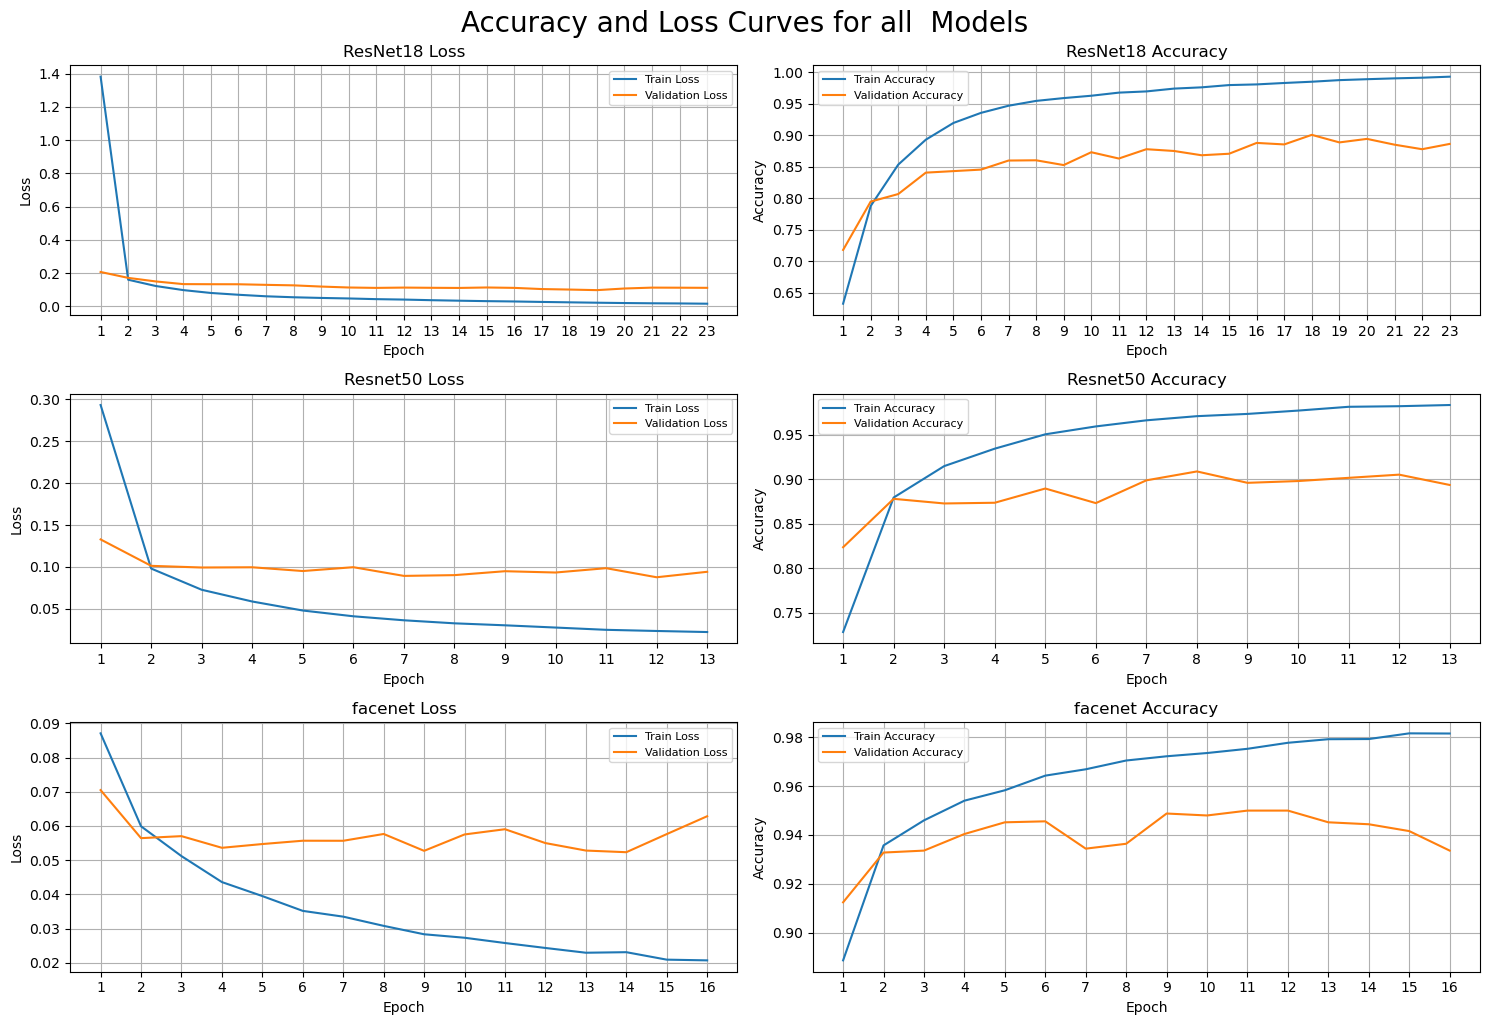

In [93]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))

model_list = ['ResNet18', 'Resnet50' , 'facenet']

for i, model in enumerate(models):
    folder = "Models/"+ model
    train_losses = np.load(os.path.join(folder, "train_losses.npy"))
    val_losses = np.load(os.path.join(folder, "val_losses.npy"))
    train_accuracies = np.load(os.path.join(folder, "train_accuracies.npy"))
    val_accuracies = np.load(os.path.join(folder, "val_accuracies.npy"))

    ax = axes[i, 0]
    ax.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
    ax.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
    ax.set_title(f"{model} Loss")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_xticks(range(1, len(train_losses) + 1))
    ax.legend(fontsize=8)
    ax.grid()

    ax = axes[i, 1]
    ax.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Train Accuracy')
    ax.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation Accuracy')
    ax.set_title(f"{model} Accuracy")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_xticks(range(1, len(train_accuracies) + 1))
    ax.legend(fontsize=8)
    ax.grid()

plt.tight_layout()
plt.suptitle("Accuracy and Loss Curves for all  Models", fontsize=20, y=1.02)
plt.show()

## Testing the model on test set

In [97]:
base = "ResNet50"
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = SiameseNetwork(base).to(device)
checkpoint_path = "Models/"+ base + "/" + base + ".pth"
assert Path(checkpoint_path).exists(), f"Checkpoint not found at {checkpoint_path}"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()
print("Model loaded successfully.")
test_set = SiameseFacePairDataset("test", transform=transform)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

/var/folders/vd/335h5jcj7cg0s8l8_29j80dm0000gn/T/ipykernel_1693/3872900450.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_pa

Model loaded successfully.


In [98]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np

threshold = 0.6

all_preds, all_labels = [], []

with torch.no_grad():
    for img1, img2, label in test_loader:
        img1, img2 = img1.to(device), img2.to(device)
        label = label.to(device)
        emb1, emb2 = model(img1, img2)
        dist = F.pairwise_distance(emb1, emb2)
        pred = (dist < threshold).float()

        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(label.cpu().numpy())

# Metrics
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)

print(f"Test Results:\nAccuracy: {acc:.4f}\nF1 Score: {f1:.4f}\nPrecision: {prec:.4f}\nRecall: {rec:.4f}")

Test Results:
Accuracy: 0.8704
F1 Score: 0.8726
Precision: 0.8578
Recall: 0.8880
